In [1]:
from pathlib import Path
import sys


current_path = Path.cwd().resolve()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

if str(project_root) not in sys.path:
    sys.path.append(
        str(project_root)
    )

print(
    "Project root:",
    project_root,
)

Project root: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    FIGURES_DIR,
    PROCESSED_DATA_DIR,
)

from src.data_loader import (
    load_enriched_data,
)

from src.eda import (
    summarize_category,
    prepare_observations,
    create_temporal_coverage_table,
    plot_temporal_coverage,
    create_indicator_coverage_summary,
    plot_confidence_distribution,
)

# Load the enriched dataset

In [4]:
enriched_df = load_enriched_data()

print(
    "Enriched dataset loaded successfully."
)

print(
    "Dataset shape:",
    enriched_df.shape,
)

Enriched dataset loaded successfully.
Dataset shape: (86, 35)


# Dataset overview
## Summary by record type

In [5]:
record_type_summary = (
    summarize_category(
        enriched_df,
        "record_type",
    )
)

record_type_summary

,record_type,record_count,percentage
0,observation,45,52.3
1,impact_link,23,26.7
2,event,15,17.4
3,target,3,3.5


## Summary by pillar

In [6]:
pillar_summary = (
    summarize_category(
        enriched_df,
        "pillar",
    )
)

pillar_summary

,pillar,record_count,percentage
0,USAGE,36,41.9
1,ACCESS,25,29.1
2,Not assigned,15,17.4
3,GENDER,6,7.0
4,AFFORDABILITY,4,4.7


## Pillar by record type

In [7]:
pillar_by_record_type = pd.crosstab(
    enriched_df["record_type"],
    enriched_df["pillar"].fillna(
        "Not assigned"
    ),
)

pillar_by_record_type

pillar,ACCESS,AFFORDABILITY,GENDER,Not assigned,USAGE
record_type,,,,,
event,0,0,0,15,0
impact_link,6,3,1,0,13
observation,17,1,4,0,23
target,2,0,1,0,0


## Summary by source type

In [8]:
source_type_summary = (
    summarize_category(
        enriched_df,
        "source_type",
    )
)

source_type_summary

,source_type,record_count,percentage
0,operator,25,29.1
1,Not assigned,23,26.7
2,regulator,13,15.1
3,survey,12,14.0
4,policy,5,5.8
5,research,4,4.7
6,calculated,2,2.3
7,news,2,2.3


## Confidence-level distribution

In [9]:
confidence_summary = (
    summarize_category(
        enriched_df,
        "confidence",
    )
)

confidence_summary

,confidence,record_count,percentage
0,high,61,70.9
1,medium,25,29.1


In [10]:
confidence_by_record_type = pd.crosstab(
    enriched_df["record_type"],
    enriched_df["confidence"].fillna(
        "Not assigned"
    ),
)

confidence_by_record_type

confidence,high,medium
record_type,,
event,15,0
impact_link,4,19
observation,40,5
target,2,1


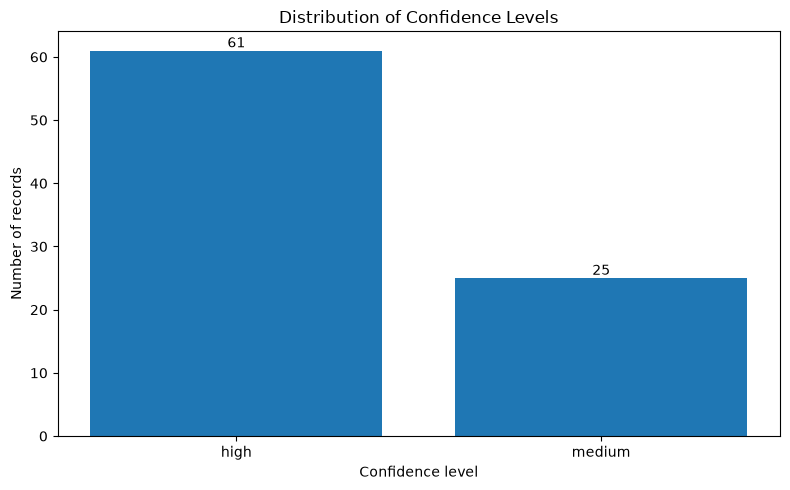

Figure saved to: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\confidence_distribution.png


In [11]:
confidence_figure_path = (
    FIGURES_DIR
    / "confidence_distribution.png"
)

confidence_figure = (
    plot_confidence_distribution(
        confidence_summary,
        confidence_figure_path,
    )
)

plt.show()

print(
    "Figure saved to:",
    confidence_figure_path,
)

## Temporal coverage

In [12]:
observations_df = (
    prepare_observations(
        enriched_df
    )
)

print(
    "Observation records:",
    len(observations_df),
)

print(
    "Earliest observation year:",
    int(
        observations_df["year"].min()
    ),
)

print(
    "Latest observation year:",
    int(
        observations_df["year"].max()
    ),
)

Observation records: 45
Earliest observation year: 2011
Latest observation year: 2025


## Observation count by year

In [13]:
observations_by_year = (
    observations_df["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

observations_by_year.columns = [
    "year",
    "observation_count",
]

observations_by_year

,year,observation_count
0,2011,1
1,2014,1
2,2017,1
3,2021,5
4,2023,1
5,2024,19
6,2025,17


In [14]:
temporal_coverage = (
    create_temporal_coverage_table(
        observations_df
    )
)

print(
    "Coverage matrix shape:",
    temporal_coverage.shape,
)

temporal_coverage

Coverage matrix shape: (27, 15)


year,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
indicator_code,,,,,,,,,,,,,,,
ACC_4G_COV,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
ACC_FAYDA,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2
ACC_MM_ACCOUNT,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
ACC_MOBILE_PEN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
ACC_OWNERSHIP,1,0,0,1,0,0,1,0,0,0,3,0,0,1,0
ACC_TELEBIRR_AGENTS,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
AFF_DATA_INCOME,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
GEN_GAP_ACC,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
GEN_GAP_MOBILE,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


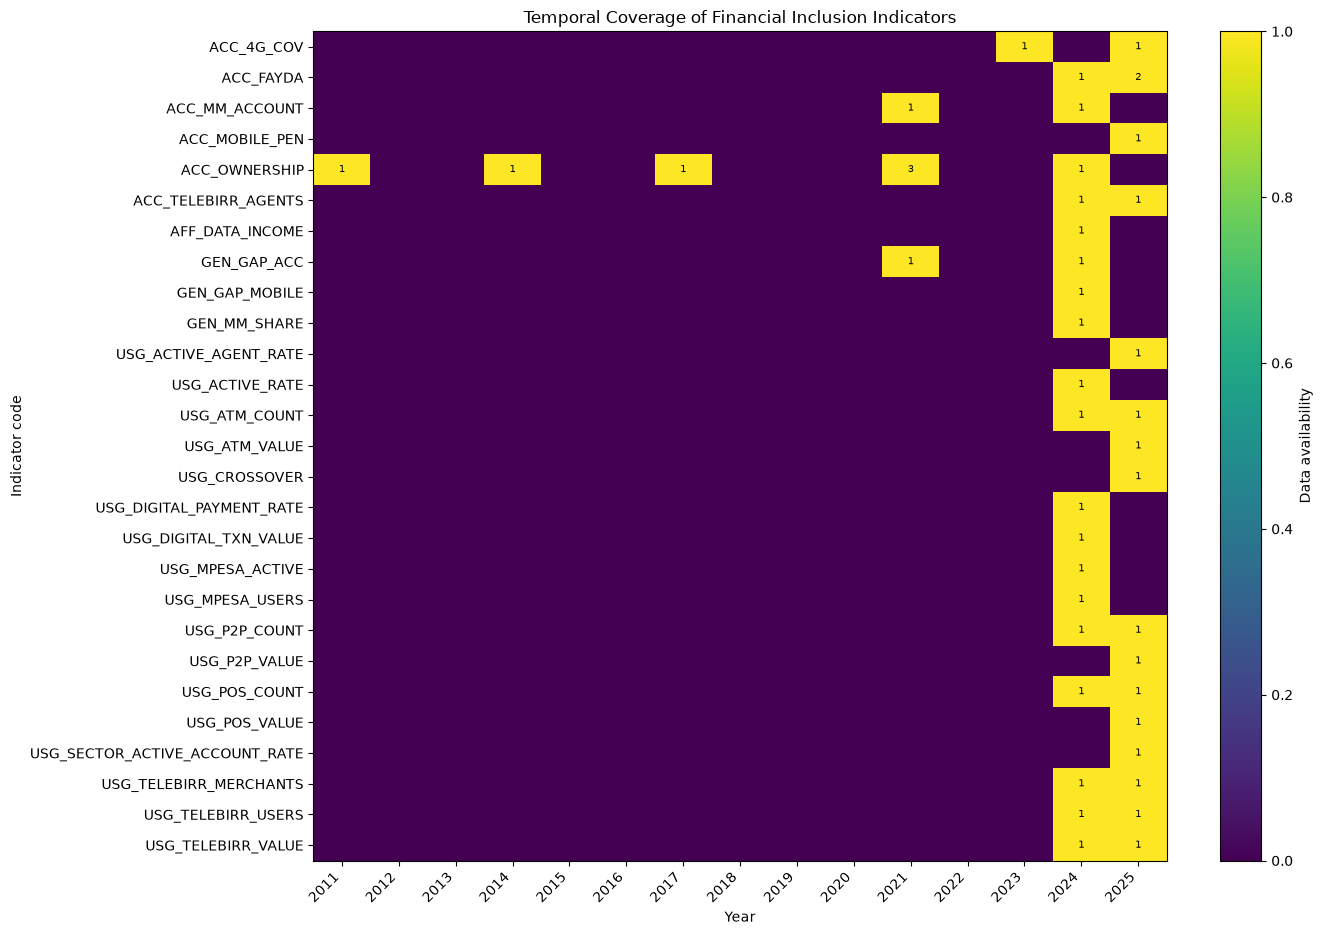

Figure saved to: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\indicator_temporal_coverage.png


In [15]:
temporal_coverage_path = (
    FIGURES_DIR
    / "indicator_temporal_coverage.png"
)

temporal_coverage_figure = (
    plot_temporal_coverage(
        temporal_coverage,
        temporal_coverage_path,
    )
)

plt.show()

print(
    "Figure saved to:",
    temporal_coverage_path,
)

# Indicator Coverage Gaps

In [16]:
indicator_coverage_summary = (
    create_indicator_coverage_summary(
        observations_df
    )
)

indicator_coverage_summary

,indicator_code,indicator,pillar,record_count,unique_years,first_year,last_year,years_covered,coverage_status
0,ACC_MOBILE_PEN,Mobile Subscription Penetration,ACCESS,1,1,2025,2025,2025,Very sparse
1,AFF_DATA_INCOME,Data Affordability Index,AFFORDABILITY,1,1,2024,2024,2024,Very sparse
2,GEN_GAP_MOBILE,Mobile Phone Gender Gap,GENDER,1,1,2024,2024,2024,Very sparse
3,GEN_MM_SHARE,Female Mobile Money Account Share,GENDER,1,1,2024,2024,2024,Very sparse
4,USG_ACTIVE_AGENT_RATE,Active Mobile Money Agent Rate,USAGE,1,1,2025,2025,2025,Very sparse
5,USG_ACTIVE_RATE,Mobile Money Activity Rate,USAGE,1,1,2024,2024,2024,Very sparse
6,USG_ATM_VALUE,ATM Transaction Value,USAGE,1,1,2025,2025,2025,Very sparse
7,USG_CROSSOVER,P2P/ATM Crossover Ratio,USAGE,1,1,2025,2025,2025,Very sparse
8,USG_DIGITAL_PAYMENT_RATE,Digital Payment Adoption Rate,USAGE,1,1,2024,2024,2024,Very sparse
9,USG_DIGITAL_TXN_VALUE,Total Digital Transaction Value,USAGE,1,1,2024,2024,2024,Very sparse


In [17]:
coverage_status_summary = (
    indicator_coverage_summary[
        "coverage_status"
    ]
    .value_counts()
    .reset_index()
)

coverage_status_summary.columns = [
    "coverage_status",
    "indicator_count",
]

coverage_status_summary

,coverage_status,indicator_count
0,Very sparse,15
1,Sparse,11
2,Relatively stronger,1


In [18]:
very_sparse_indicators = (
    indicator_coverage_summary[
        indicator_coverage_summary[
            "coverage_status"
        ] == "Very sparse"
    ]
    .reset_index(drop=True)
)

very_sparse_indicators[
    [
        "indicator_code",
        "indicator",
        "pillar",
        "record_count",
        "years_covered",
    ]
]

,indicator_code,indicator,pillar,record_count,years_covered
0,ACC_MOBILE_PEN,Mobile Subscription Penetration,ACCESS,1,2025
1,AFF_DATA_INCOME,Data Affordability Index,AFFORDABILITY,1,2024
2,GEN_GAP_MOBILE,Mobile Phone Gender Gap,GENDER,1,2024
3,GEN_MM_SHARE,Female Mobile Money Account Share,GENDER,1,2024
4,USG_ACTIVE_AGENT_RATE,Active Mobile Money Agent Rate,USAGE,1,2025
5,USG_ACTIVE_RATE,Mobile Money Activity Rate,USAGE,1,2024
6,USG_ATM_VALUE,ATM Transaction Value,USAGE,1,2025
7,USG_CROSSOVER,P2P/ATM Crossover Ratio,USAGE,1,2025
8,USG_DIGITAL_PAYMENT_RATE,Digital Payment Adoption Rate,USAGE,1,2024
9,USG_DIGITAL_TXN_VALUE,Total Digital Transaction Value,USAGE,1,2024


In [19]:
sparse_indicators = (
    indicator_coverage_summary[
        indicator_coverage_summary[
            "coverage_status"
        ].isin(
            [
                "Sparse",
                "Limited",
            ]
        )
    ]
    .reset_index(drop=True)
)

sparse_indicators[
    [
        "indicator_code",
        "indicator",
        "pillar",
        "record_count",
        "unique_years",
        "years_covered",
        "coverage_status",
    ]
]

,indicator_code,indicator,pillar,record_count,unique_years,years_covered,coverage_status
0,ACC_4G_COV,4G Population Coverage,ACCESS,2,2,"2023, 2025",Sparse
1,ACC_MM_ACCOUNT,Mobile Money Account Rate,ACCESS,2,2,"2021, 2024",Sparse
2,ACC_TELEBIRR_AGENTS,Telebirr Agent Count,ACCESS,2,2,"2024, 2025",Sparse
3,GEN_GAP_ACC,Account Ownership Gender Gap,GENDER,2,2,"2021, 2024",Sparse
4,USG_ATM_COUNT,ATM Transaction Count,USAGE,2,2,"2024, 2025",Sparse
5,USG_P2P_COUNT,P2P Transaction Count,USAGE,2,2,"2024, 2025",Sparse
6,USG_POS_COUNT,POS Transaction Count,USAGE,2,2,"2024, 2025",Sparse
7,USG_TELEBIRR_MERCHANTS,Telebirr Merchant Count,USAGE,2,2,"2024, 2025",Sparse
8,USG_TELEBIRR_USERS,Telebirr Registered Users,USAGE,2,2,"2024, 2025",Sparse
9,USG_TELEBIRR_VALUE,Telebirr Transaction Value,USAGE,2,2,"2024, 2025",Sparse


In [20]:
stronger_coverage_indicators = (
    indicator_coverage_summary[
        indicator_coverage_summary[
            "coverage_status"
        ] == "Relatively stronger"
    ]
    .sort_values(
        [
            "unique_years",
            "record_count",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

stronger_coverage_indicators[
    [
        "indicator_code",
        "indicator",
        "pillar",
        "record_count",
        "unique_years",
        "years_covered",
    ]
]

,indicator_code,indicator,pillar,record_count,unique_years,years_covered
0,ACC_OWNERSHIP,Account Ownership Rate,ACCESS,7,5,"2011, 2014, 2017, 2021, 2024"


In [21]:
print("=" * 60)
print("EXPLORATORY DATA OVERVIEW SUMMARY")
print("=" * 60)

print(
    "\nTotal records:",
    len(enriched_df),
)

print(
    "Observation records:",
    len(observations_df),
)

print(
    "Unique observation indicators:",
    observations_df[
        "indicator_code"
    ].nunique(),
)

print(
    "Observation period:",
    int(
        observations_df["year"].min()
    ),
    "to",
    int(
        observations_df["year"].max()
    ),
)

print(
    "\nVery sparse indicators:",
    len(very_sparse_indicators),
)

print(
    "Sparse or limited indicators:",
    len(sparse_indicators),
)

print(
    "Relatively stronger indicators:",
    len(stronger_coverage_indicators),
)

print(
    "\nTemporal coverage figure:",
    temporal_coverage_path,
)

print(
    "Confidence figure:",
    confidence_figure_path,
)

EXPLORATORY DATA OVERVIEW SUMMARY

Total records: 86
Observation records: 45
Unique observation indicators: 27
Observation period: 2011 to 2025

Very sparse indicators: 15
Sparse or limited indicators: 11
Relatively stronger indicators: 1

Temporal coverage figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\indicator_temporal_coverage.png
Confidence figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\confidence_distribution.png


# Access Analysis

In [22]:
from src.access_analysis import (
    get_account_ownership_trajectory,
    calculate_ownership_growth,
    plot_account_ownership,
    plot_ownership_growth,
    get_gender_ownership,
    plot_gender_ownership,
    get_gender_gap_trend,
    plot_gender_gap,
    get_urban_rural_ownership,
    plot_urban_rural_ownership,
    get_slowdown_context,
    get_access_event_timeline,
)

## Account ownership trajectory

In [23]:
ownership_trajectory = (
    get_account_ownership_trajectory(
        enriched_df
    )
)

ownership_trajectory

,record_id,year,ownership_rate,unit,source_name,confidence
0,REC_0034,2011,14.0,%,Global Findex 2011,high
1,REC_0001,2014,22.0,%,Global Findex 2014,high
2,REC_0002,2017,35.0,%,Global Findex 2017,high
3,REC_0003,2021,46.0,%,Global Findex 2021,high
4,REC_0006,2024,49.0,%,Global Findex 2024,high


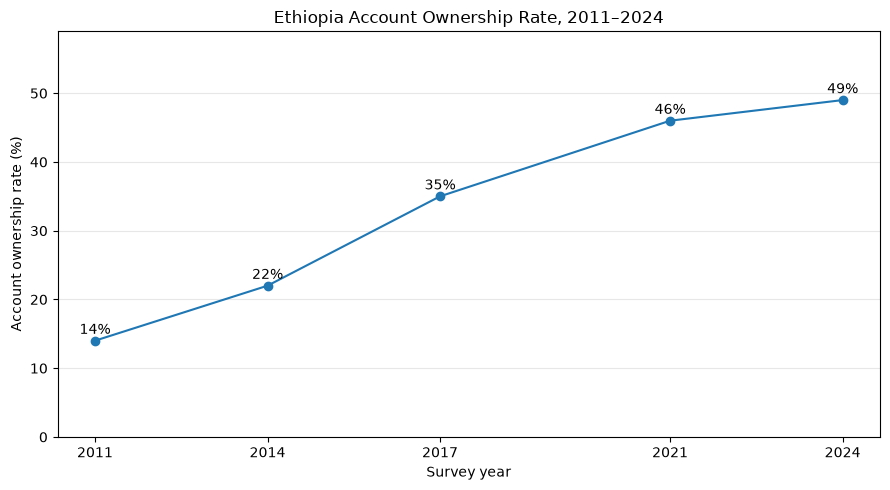

Figure saved to: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\account_ownership_trajectory.png


In [24]:
ownership_trajectory_path = (
    FIGURES_DIR
    / "account_ownership_trajectory.png"
)

ownership_figure = (
    plot_account_ownership(
        ownership_trajectory,
        ownership_trajectory_path,
    )
)

plt.show()

print(
    "Figure saved to:",
    ownership_trajectory_path,
)

## Growth between survey years

In [25]:
ownership_growth = (
    calculate_ownership_growth(
        ownership_trajectory
    )
)

ownership_growth[
    [
        "period",
        "previous_rate",
        "ownership_rate",
        "years_between",
        "percentage_point_change",
        "annual_pp_change",
        "relative_growth_percent",
    ]
]

,period,previous_rate,ownership_rate,years_between,percentage_point_change,annual_pp_change,relative_growth_percent
0,2011-2014,14.0,22.0,3.0,8.0,2.67,57.14
1,2014-2017,22.0,35.0,3.0,13.0,4.33,59.09
2,2017-2021,35.0,46.0,4.0,11.0,2.75,31.43
3,2021-2024,46.0,49.0,3.0,3.0,1.00,6.52


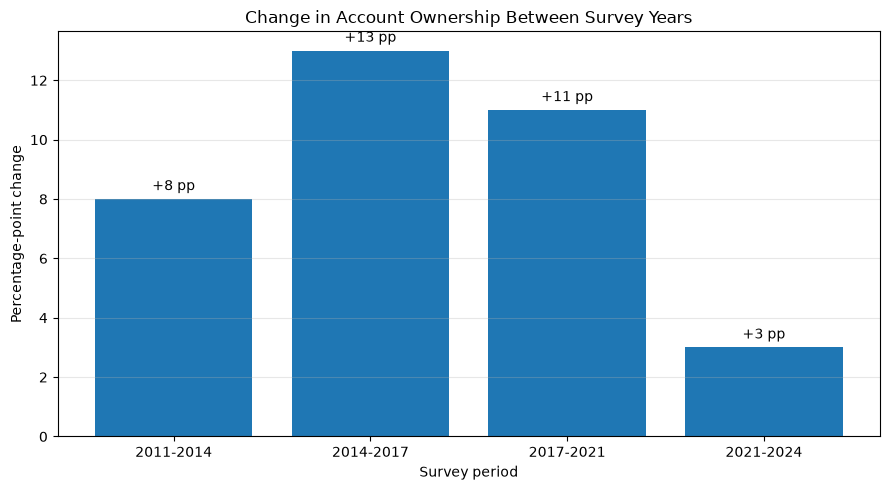

Figure saved to: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\account_ownership_growth.png


In [41]:
ownership_growth_path = (
    FIGURES_DIR
    / "account_ownership_growth.png"
)

growth_figure = (
    plot_ownership_growth(
        ownership_growth,
        ownership_growth_path,
    )
)

plt.show()

print(
    "Figure saved to:",
    ownership_growth_path,
)

In [26]:
slowdown_periods = ownership_growth[
    ownership_growth["period"].isin(
        [
            "2017-2021",
            "2021-2024",
        ]
    )
][
    [
        "period",
        "percentage_point_change",
        "annual_pp_change",
        "relative_growth_percent",
    ]
].reset_index(drop=True)

slowdown_periods

,period,percentage_point_change,annual_pp_change,relative_growth_percent
0,2017-2021,11.0,2.75,31.43
1,2021-2024,3.0,1.00,6.52


## the slowdown

In [27]:
previous_growth = slowdown_periods.loc[
    slowdown_periods["period"]
    == "2017-2021",
    "annual_pp_change",
].iloc[0]

recent_growth = slowdown_periods.loc[
    slowdown_periods["period"]
    == "2021-2024",
    "annual_pp_change",
].iloc[0]

annual_growth_slowdown = (
    previous_growth
    - recent_growth
)

slowdown_percentage = (
    annual_growth_slowdown
    / previous_growth
    * 100
)

print(
    "Annual percentage-point growth, 2017-2021:",
    round(previous_growth, 2),
)

print(
    "Annual percentage-point growth, 2021-2024:",
    round(recent_growth, 2),
)

print(
    "Reduction in annual growth:",
    round(annual_growth_slowdown, 2),
    "percentage points per year",
)

print(
    "Relative slowdown:",
    round(slowdown_percentage, 1),
    "%",
)

Annual percentage-point growth, 2017-2021: 2.75
Annual percentage-point growth, 2021-2024: 1.0
Reduction in annual growth: 1.75 percentage points per year
Relative slowdown: 63.6 %


## Gender analysis

In [28]:
gender_ownership = (
    get_gender_ownership(
        enriched_df
    )
)

gender_ownership

,year,gender,ownership_rate,unit,confidence
0,2021,female,36.0,%,high
1,2021,male,56.0,%,high


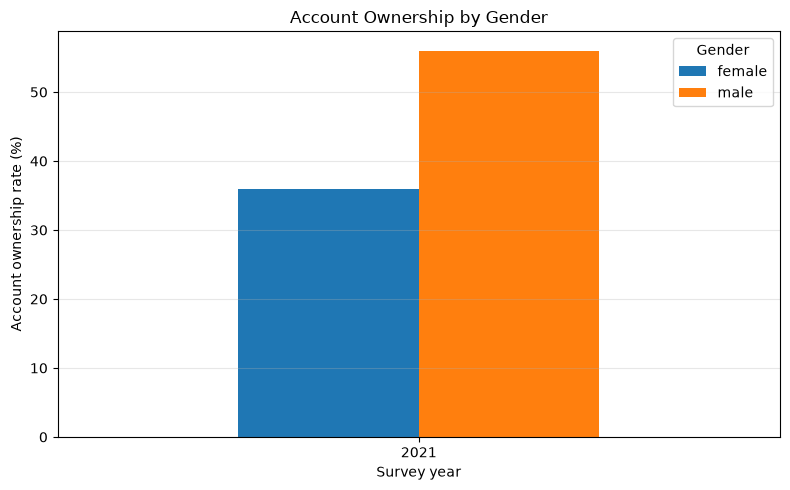

Figure saved to: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\account_ownership_by_gender.png


In [29]:
if gender_ownership.empty:

    print(
        "No male and female account ownership "
        "observations are available."
    )

else:

    gender_ownership_path = (
        FIGURES_DIR
        / "account_ownership_by_gender.png"
    )

    gender_figure = (
        plot_gender_ownership(
            gender_ownership,
            gender_ownership_path,
        )
    )

    plt.show()

    print(
        "Figure saved to:",
        gender_ownership_path,
    )

In [40]:
gender_gap_trend = (
    get_gender_gap_trend(
        enriched_df
    )
)

gender_gap_trend

,year,gender_gap,unit,source_name,confidence
0,2021,20.0,pp,Global Findex 2021,high
1,2024,18.0,pp,Global Findex 2024,medium


## Urban versus rural ownership

In [31]:
urban_rural_ownership = (
    get_urban_rural_ownership(
        enriched_df
    )
)

urban_rural_ownership

,year,location,ownership_rate,unit,confidence


## Investigate the 2021–2024 slowdown

In [32]:
slowdown_context = (
    get_slowdown_context(
        enriched_df
    )
)

slowdown_context

,indicator_code,indicator,possible_role,year,value_numeric,unit,confidence
0,USG_DIGITAL_PAYMENT_RATE,Digital Payment Adoption Rate,Actual digital usage,2024,35.00,%,medium
1,AFF_DATA_INCOME,Data Affordability Index,Affordability constraint,2024,2.00,% of GNI,medium
2,ACC_4G_COV,4G Population Coverage,Digital infrastructure,2025,70.80,%,high
3,ACC_MM_ACCOUNT,Mobile Money Account Rate,Direct mobile money access,2024,9.45,%,high
4,ACC_FAYDA,Fayda Digital ID Enrollment,Identification and KYC,2025,15000000.00,people,high
5,USG_TELEBIRR_MERCHANTS,Telebirr Merchant Count,Merchant acceptance,2025,310100.00,merchants,high
6,ACC_TELEBIRR_AGENTS,Telebirr Agent Count,Physical service reach,2025,320300.00,agents,high
7,USG_MPESA_USERS,M-Pesa Registered Users,Registered wallet scale,2024,10800000.00,users,high
8,USG_TELEBIRR_USERS,Telebirr Registered Users,Registered wallet scale,2025,54840000.00,users,high
9,USG_ACTIVE_RATE,Mobile Money Activity Rate,Registered-to-active conversion,2024,66.00,%,high


In [33]:
slowdown_event_timeline = (
    get_access_event_timeline(
        enriched_df,
        start_year=2021,
        end_year=2024,
    )
)

slowdown_event_timeline

,record_id,year,observation_date,category,indicator,confidence
0,EVT_0001,2021,2021-05-17,product_launch,Telebirr Launch,high
1,EVT_0009,2021,2021-09-01,policy,NFIS-II Strategy Launch,high
2,EVT_0002,2022,2022-08-01,market_entry,Safaricom Ethiopia Commercial Launch,high
3,EVT_0003,2023,2023-08-01,product_launch,M-Pesa Ethiopia Launch,high
4,EVT_0011,2023,2023-10-09,regulation,Revised Payment Instrument Issuer Directive,high
5,EVT_0004,2024,2024-01-01,infrastructure,Fayda Digital ID Program Rollout,high
6,EVT_0012,2024,2024-02-29,policy,National Financial Education Module Launch,high
7,EVT_0013,2024,2024-04-05,regulation,National Interoperable QR Payment Standard Launch,high
8,EVT_0005,2024,2024-07-29,policy,Foreign Exchange Liberalization,high
9,EVT_0006,2024,2024-10-01,milestone,P2P Transaction Count Surpasses ATM,high


## registration versus active use

In [34]:
registration_activity_codes = [
    "ACC_MM_ACCOUNT",
    "USG_TELEBIRR_USERS",
    "USG_MPESA_USERS",
    "USG_ACTIVE_RATE",
    "USG_SECTOR_ACTIVE_ACCOUNT_RATE",
]

registration_activity_evidence = (
    slowdown_context[
        slowdown_context[
            "indicator_code"
        ].isin(
            registration_activity_codes
        )
    ]
    .reset_index(drop=True)
)

registration_activity_evidence

,indicator_code,indicator,possible_role,year,value_numeric,unit,confidence
0,ACC_MM_ACCOUNT,Mobile Money Account Rate,Direct mobile money access,2024,9.45,%,high
1,USG_MPESA_USERS,M-Pesa Registered Users,Registered wallet scale,2024,10800000.00,users,high
2,USG_TELEBIRR_USERS,Telebirr Registered Users,Registered wallet scale,2025,54840000.00,users,high
3,USG_ACTIVE_RATE,Mobile Money Activity Rate,Registered-to-active conversion,2024,66.00,%,high
4,USG_SECTOR_ACTIVE_ACCOUNT_RATE,Sector Active Mobile Money Account Rate,Registered-to-active conversion,2025,15.00,%,medium


## Access constraints and enablers

In [35]:
access_factor_codes = [
    "ACC_4G_COV",
    "ACC_FAYDA",
    "GEN_GAP_ACC",
    "AFF_DATA_INCOME",
    "ACC_TELEBIRR_AGENTS",
]

access_factor_evidence = (
    slowdown_context[
        slowdown_context[
            "indicator_code"
        ].isin(
            access_factor_codes
        )
    ]
    .reset_index(drop=True)
)

access_factor_evidence

,indicator_code,indicator,possible_role,year,value_numeric,unit,confidence
0,AFF_DATA_INCOME,Data Affordability Index,Affordability constraint,2024,2.0,% of GNI,medium
1,ACC_4G_COV,4G Population Coverage,Digital infrastructure,2025,70.8,%,high
2,ACC_FAYDA,Fayda Digital ID Enrollment,Identification and KYC,2025,15000000.0,people,high
3,ACC_TELEBIRR_AGENTS,Telebirr Agent Count,Physical service reach,2025,320300.0,agents,high
4,GEN_GAP_ACC,Account Ownership Gender Gap,Unequal access,2024,18.0,pp,medium


In [36]:
slowdown_hypotheses = pd.DataFrame({
    "possible_explanation": [
        "Registered accounts may not represent unique newly included adults",
        "Many registered accounts may be inactive",
        "Mobile money users may already own bank accounts",
        "Gender and geographic access gaps may remain",
        "Product launches may take time to affect survey outcomes",
        "Affordability and service access may limit conversion",
        "Rapid adult population growth may dilute gains in absolute account numbers",
    ],

    "why_it_matters": [
        (
            "One person may hold multiple wallets, and "
            "operator registrations may include duplicates."
        ),
        (
            "Inactive wallets may not satisfy Findex's "
            "recent-use definition for mobile money."
        ),
        (
            "Mobile money growth may deepen usage without "
            "adding the same number of new account owners."
        ),
        (
            "Growth can remain concentrated among already "
            "better-served groups."
        ),
        (
            "Telebirr launched in 2021 and M-Pesa in 2023, "
            "leaving limited time before the 2024 survey."
        ),
        (
            "Coverage growth alone may not overcome data, "
            "device, transaction, or agent-service costs."
        ),
        (
            "Account ownership is measured as a share of "
            "adults rather than as an absolute account count."
        ),
    ],

    "evidence_status": [
        "Partially supported by registration data",
        "Supported by activity-rate indicators",
        "Requires customer-level overlap data",
        "Partially supported by gender data; regional data missing",
        "Supported by event timing",
        "Partially supported; more annual affordability data required",
        "Requires adult population data",
    ],
})

slowdown_hypotheses

,possible_explanation,why_it_matters,evidence_status
0,Registered accounts may not represent unique n...,"One person may hold multiple wallets, and oper...",Partially supported by registration data
1,Many registered accounts may be inactive,Inactive wallets may not satisfy Findex's rece...,Supported by activity-rate indicators
2,Mobile money users may already own bank accounts,Mobile money growth may deepen usage without a...,Requires customer-level overlap data
3,Gender and geographic access gaps may remain,Growth can remain concentrated among already b...,Partially supported by gender data; regional d...
4,Product launches may take time to affect surve...,"Telebirr launched in 2021 and M-Pesa in 2023, ...",Supported by event timing
5,Affordability and service access may limit con...,"Coverage growth alone may not overcome data, d...",Partially supported; more annual affordability...
6,Rapid adult population growth may dilute gains...,Account ownership is measured as a share of ad...,Requires adult population data


In [42]:
print("=" * 60)
print("ACCESS ANALYSIS SUMMARY")
print("=" * 60)

print(
    "\nNational ownership observations:",
    len(ownership_trajectory),
)

print(
    "Ownership period:",
    int(
        ownership_trajectory["year"].min()
    ),
    "to",
    int(
        ownership_trajectory["year"].max()
    ),
)

print(
    "Overall ownership change:",
    round(
        ownership_trajectory[
            "ownership_rate"
        ].iloc[-1]
        - ownership_trajectory[
            "ownership_rate"
        ].iloc[0],
        2,
    ),
    "percentage points",
)

print(
    "\n2021-2024 change:",
    round(
        ownership_growth.loc[
            ownership_growth["period"]
            == "2021-2024",
            "percentage_point_change",
        ].iloc[0],
        2,
    ),
    "percentage points",
)

print(
    "Relative slowdown in annual growth:",
    round(
        slowdown_percentage,
        1,
    ),
    "%",
)

print(
    "\nGender-disaggregated records:",
    len(gender_ownership),
)

print(
    "Gender-gap records:",
    len(gender_gap_trend),
)

print(
    "Urban/rural records:",
    len(urban_rural_ownership),
)

print(
    "\nTrajectory figure:",
    ownership_trajectory_path,
)

print(
    "Growth figure:",
    ownership_growth_path,
)

ACCESS ANALYSIS SUMMARY

National ownership observations: 5
Ownership period: 2011 to 2024
Overall ownership change: 35.0 percentage points

2021-2024 change: 3.0 percentage points
Relative slowdown in annual growth: 63.6 %

Gender-disaggregated records: 2
Gender-gap records: 2
Urban/rural records: 0

Trajectory figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\account_ownership_trajectory.png
Growth figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\account_ownership_growth.png


# Digital Payments Analysis

In [43]:
from src.usage_analysis import (
    get_indicator_series,
    get_registered_active_gap,
    get_transaction_counts,
)

## Mobile money account penetration

In [44]:
mobile_money_penetration = (
    get_indicator_series(
        enriched_df,
        "ACC_MM_ACCOUNT",
    )
)

mobile_money_penetration

,year,indicator_code,indicator,value_numeric,unit,confidence
0,2021,ACC_MM_ACCOUNT,Mobile Money Account Rate,4.70,%,high
1,2024,ACC_MM_ACCOUNT,Mobile Money Account Rate,9.45,%,high


In [45]:
expected_survey_years = [
    2014,
    2017,
    2021,
    2024,
]

available_years = (
    mobile_money_penetration["year"]
    .dropna()
    .astype(int)
    .tolist()
)

missing_years = [
    year
    for year in expected_survey_years
    if year not in available_years
]

print("Available years:", available_years)
print("Missing survey years:", missing_years)

Available years: [2021, 2024]
Missing survey years: [2014, 2017]


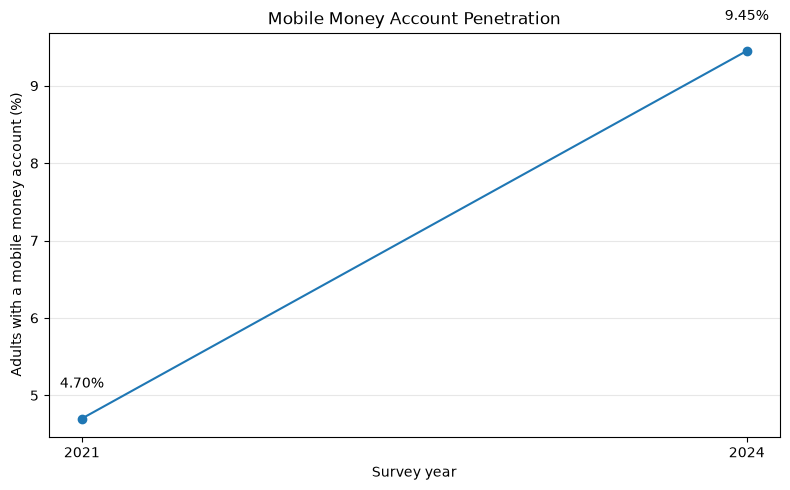

In [46]:
mobile_money_path = (
    FIGURES_DIR
    / "mobile_money_account_penetration.png"
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    mobile_money_penetration["year"],
    mobile_money_penetration["value_numeric"],
    marker="o",
)

for _, row in mobile_money_penetration.iterrows():
    ax.text(
        row["year"],
        row["value_numeric"] + 0.4,
        f'{row["value_numeric"]:.2f}%',
        ha="center",
    )

ax.set_title(
    "Mobile Money Account Penetration"
)

ax.set_xlabel("Survey year")
ax.set_ylabel("Adults with a mobile money account (%)")

ax.set_xticks(
    mobile_money_penetration["year"]
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

fig.savefig(
    mobile_money_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [47]:
digital_payment_adoption = (
    get_indicator_series(
        enriched_df,
        "USG_DIGITAL_PAYMENT_RATE",
    )
)

digital_payment_adoption

,year,indicator_code,indicator,value_numeric,unit,confidence
0,2024,USG_DIGITAL_PAYMENT_RATE,Digital Payment Adoption Rate,35.0,%,medium


In [48]:
usage_comparison = pd.concat(
    [
        mobile_money_penetration[
            mobile_money_penetration["year"]
            == 2024
        ].assign(
            measure="Mobile money account"
        ),

        digital_payment_adoption.assign(
            measure="Made or received digital payment"
        ),
    ],
    ignore_index=True,
)

usage_comparison[
    [
        "year",
        "measure",
        "value_numeric",
        "unit",
        "confidence",
    ]
]

,year,measure,value_numeric,unit,confidence
0,2024,Mobile money account,9.45,%,high
1,2024,Made or received digital payment,35.00,%,medium


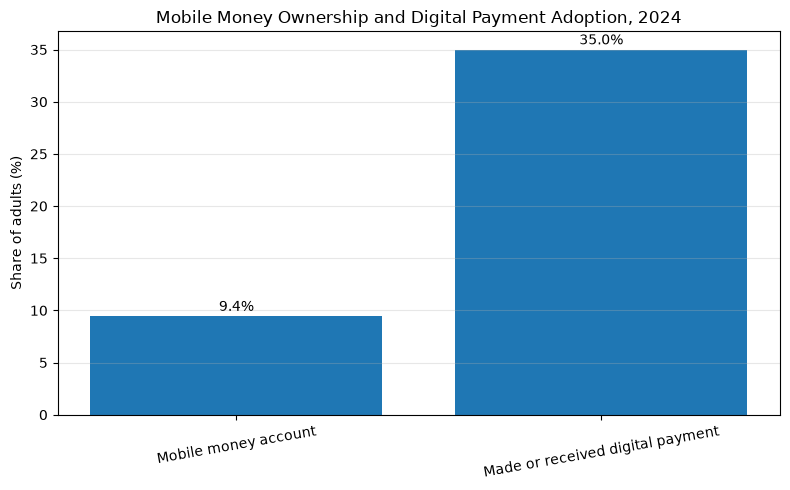

In [49]:
adoption_comparison_path = (
    FIGURES_DIR
    / "digital_payment_adoption_2024.png"
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    usage_comparison["measure"],
    usage_comparison["value_numeric"],
)

for bar, value in zip(
    bars,
    usage_comparison["value_numeric"],
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
    )

ax.set_title(
    "Mobile Money Ownership and Digital Payment Adoption, 2024"
)

ax.set_ylabel("Share of adults (%)")
ax.tick_params(
    axis="x",
    rotation=10,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

fig.savefig(
    adoption_comparison_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Registered versus active users

In [50]:
registered_active_gap = (
    get_registered_active_gap(
        enriched_df
    )
)

registered_active_gap

,year,registered_users,active_users,inactive_users,calculated_active_rate
0,2024,10800000.0,7100000.0,3700000.0,65.7


In [51]:
reported_activity_rate = (
    get_indicator_series(
        enriched_df,
        "USG_ACTIVE_RATE",
    )
)

reported_activity_rate

,year,indicator_code,indicator,value_numeric,unit,confidence
0,2024,USG_ACTIVE_RATE,Mobile Money Activity Rate,66.0,%,high


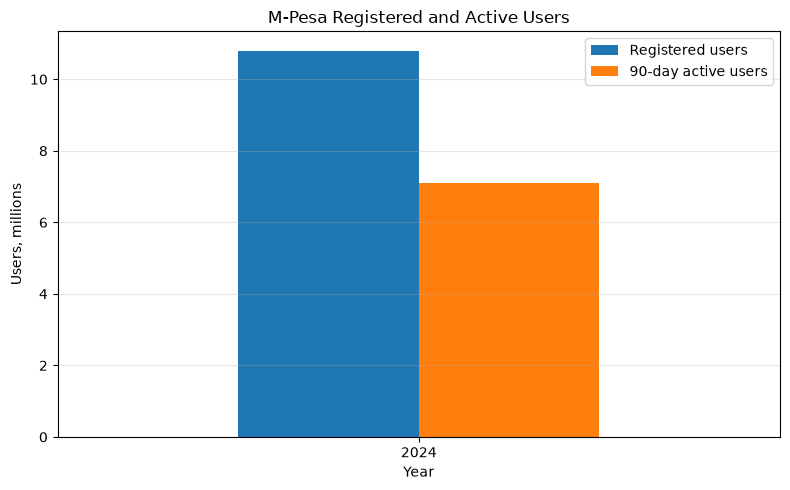

In [52]:
registered_active_path = (
    FIGURES_DIR
    / "mpesa_registered_vs_active.png"
)

gap_plot = registered_active_gap.copy()

gap_plot[
    [
        "registered_users",
        "active_users",
    ]
] = (
    gap_plot[
        [
            "registered_users",
            "active_users",
        ]
    ]
    / 1_000_000
)

gap_plot = gap_plot.set_index("year")

ax = gap_plot[
    [
        "registered_users",
        "active_users",
    ]
].plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title(
    "M-Pesa Registered and Active Users"
)

ax.set_xlabel("Year")
ax.set_ylabel("Users, millions")
ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    [
        "Registered users",
        "90-day active users",
    ]
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

fig = ax.get_figure()

fig.savefig(
    registered_active_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Payment use cases

In [53]:
transaction_counts = (
    get_transaction_counts(
        enriched_df
    )
)

transaction_counts

,year,payment_channel,value_numeric,transactions_millions,confidence
0,2024,ATM,94527740.0,94.527740,high
1,2024,Merchant/POS,2181365.0,2.181365,high
2,2024,P2P,49700000.0,49.700000,high
3,2025,ATM,119300000.0,119.300000,high
4,2025,Merchant/POS,2780000.0,2.780000,high
5,2025,P2P,128300000.0,128.300000,high


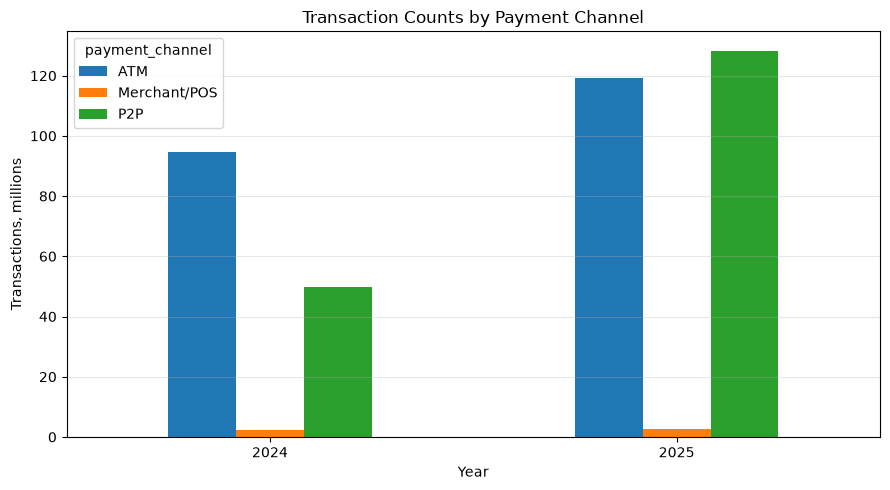

In [54]:
payment_use_case_path = (
    FIGURES_DIR
    / "payment_channel_transaction_counts.png"
)

transaction_pivot = (
    transaction_counts
    .pivot_table(
        index="year",
        columns="payment_channel",
        values="transactions_millions",
    )
)

ax = transaction_pivot.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Transaction Counts by Payment Channel"
)

ax.set_xlabel("Year")
ax.set_ylabel("Transactions, millions")
ax.tick_params(
    axis="x",
    rotation=0,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

fig = ax.get_figure()

fig.savefig(
    payment_use_case_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [55]:
p2p_atm_comparison = (
    transaction_counts[
        transaction_counts[
            "payment_channel"
        ].isin(
            [
                "P2P",
                "ATM",
            ]
        )
    ]
    .pivot_table(
        index="year",
        columns="payment_channel",
        values="transactions_millions",
    )
    .reset_index()
)

if {
    "P2P",
    "ATM",
}.issubset(
    p2p_atm_comparison.columns
):

    p2p_atm_comparison[
        "p2p_to_atm_ratio"
    ] = (
        p2p_atm_comparison["P2P"]
        / p2p_atm_comparison["ATM"]
    ).round(2)

p2p_atm_comparison

payment_channel,year,ATM,P2P,p2p_to_atm_ratio
0,2024,94.52774,49.7,0.53
1,2025,119.30000,128.3,1.08


In [57]:
observations = enriched_df[
    enriched_df["record_type"]
    == "observation"
].copy()

use_case_patterns = {
    "P2P transfers": "p2p",
    "Merchant payments": "merchant|pos",
    "Bill payments": "bill",
    "Wage payments": "wage|salary",
}

use_case_coverage = []

for use_case, pattern in use_case_patterns.items():

    matches = observations[
        observations["indicator"]
        .str.contains(
            pattern,
            case=False,
            na=False,
            regex=True,
        )
    ]

    use_case_coverage.append({
        "use_case": use_case,
        "indicator_count": (
            matches["indicator_code"]
            .nunique()
        ),
        "available_indicators": ", ".join(
            sorted(
                matches["indicator_code"]
                .dropna()
                .unique()
            )
        ) or "Not available",
    })

use_case_coverage = pd.DataFrame(
    use_case_coverage
)

use_case_coverage

,use_case,indicator_count,available_indicators
0,P2P transfers,3,"USG_CROSSOVER, USG_P2P_COUNT, USG_P2P_VALUE"
1,Merchant payments,3,"USG_POS_COUNT, USG_POS_VALUE, USG_TELEBIRR_MER..."
2,Bill payments,0,Not available
3,Wage payments,0,Not available


In [58]:
print("=" * 60)
print("USAGE ANALYSIS SUMMARY")
print("=" * 60)

print(
    "\nMobile money penetration observations:",
    len(mobile_money_penetration),
)

print(
    "Available penetration years:",
    available_years,
)

print(
    "Missing survey years:",
    missing_years,
)

print(
    "\nDigital payment adoption observations:",
    len(digital_payment_adoption),
)

print(
    "Registered-active comparisons:",
    len(registered_active_gap),
)

print(
    "Payment-channel observations:",
    len(transaction_counts),
)

print(
    "\nUse cases without indicators:"
)

print(
    use_case_coverage.loc[
        use_case_coverage[
            "indicator_count"
        ] == 0,
        "use_case",
    ].tolist()
)

print(
    "\nMobile money figure:",
    mobile_money_path,
)

print(
    "Digital adoption figure:",
    adoption_comparison_path,
)

print(
    "Registered-active figure:",
    registered_active_path,
)

print(
    "Payment-use-case figure:",
    payment_use_case_path,
)

USAGE ANALYSIS SUMMARY

Mobile money penetration observations: 2
Available penetration years: [2021, 2024]
Missing survey years: [2014, 2017]

Digital payment adoption observations: 1
Registered-active comparisons: 1
Payment-channel observations: 6

Use cases without indicators:
['Bill payments', 'Wage payments']

Mobile money figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\mobile_money_account_penetration.png
Digital adoption figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\digital_payment_adoption_2024.png
Registered-active figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\mpesa_registered_vs_active.png
Payment-use-case figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\payment_channel_transaction_counts.png


# Infrastructure and Enablers

In [59]:
infrastructure_codes = [
    "ACC_4G_COV",
    "ACC_MOBILE_PEN",
    "ACC_TELEBIRR_AGENTS",
    "ACC_FAYDA",
    "USG_TELEBIRR_MERCHANTS",
]

infrastructure_data = (
    observations_df[
        observations_df["indicator_code"]
        .isin(infrastructure_codes)
    ][
        [
            "year",
            "indicator_code",
            "indicator",
            "value_numeric",
            "unit",
            "confidence",
        ]
    ]
    .sort_values(
        [
            "indicator_code",
            "year",
        ]
    )
    .reset_index(drop=True)
)

infrastructure_data

,year,indicator_code,indicator,value_numeric,unit,confidence
0,2023,ACC_4G_COV,4G Population Coverage,37.5,%,high
1,2025,ACC_4G_COV,4G Population Coverage,70.8,%,high
2,2024,ACC_FAYDA,Fayda Digital ID Enrollment,8000000.0,people,high
3,2025,ACC_FAYDA,Fayda Digital ID Enrollment,12000000.0,people,high
4,2025,ACC_FAYDA,Fayda Digital ID Enrollment,15000000.0,people,high
5,2025,ACC_MOBILE_PEN,Mobile Subscription Penetration,61.4,%,high
6,2024,ACC_TELEBIRR_AGENTS,Telebirr Agent Count,216000.0,agents,high
7,2025,ACC_TELEBIRR_AGENTS,Telebirr Agent Count,320300.0,agents,high
8,2024,USG_TELEBIRR_MERCHANTS,Telebirr Merchant Count,196000.0,merchants,high
9,2025,USG_TELEBIRR_MERCHANTS,Telebirr Merchant Count,310100.0,merchants,high


In [60]:
infrastructure_summary = (
    infrastructure_data
    .groupby(
        [
            "indicator_code",
            "indicator",
            "unit",
        ],
        dropna=False,
    )
    .agg(
        observation_count=(
            "year",
            "count",
        ),
        first_year=(
            "year",
            "min",
        ),
        last_year=(
            "year",
            "max",
        ),
        years_available=(
            "year",
            lambda values: ", ".join(
                str(int(year))
                for year in sorted(
                    values.dropna().unique()
                )
            ),
        ),
    )
    .reset_index()
)

infrastructure_summary

,indicator_code,indicator,unit,observation_count,first_year,last_year,years_available
0,ACC_4G_COV,4G Population Coverage,%,2,2023,2025,"2023, 2025"
1,ACC_FAYDA,Fayda Digital ID Enrollment,people,3,2024,2025,"2024, 2025"
2,ACC_MOBILE_PEN,Mobile Subscription Penetration,%,1,2025,2025,2025
3,ACC_TELEBIRR_AGENTS,Telebirr Agent Count,agents,2,2024,2025,"2024, 2025"
4,USG_TELEBIRR_MERCHANTS,Telebirr Merchant Count,merchants,2,2024,2025,"2024, 2025"


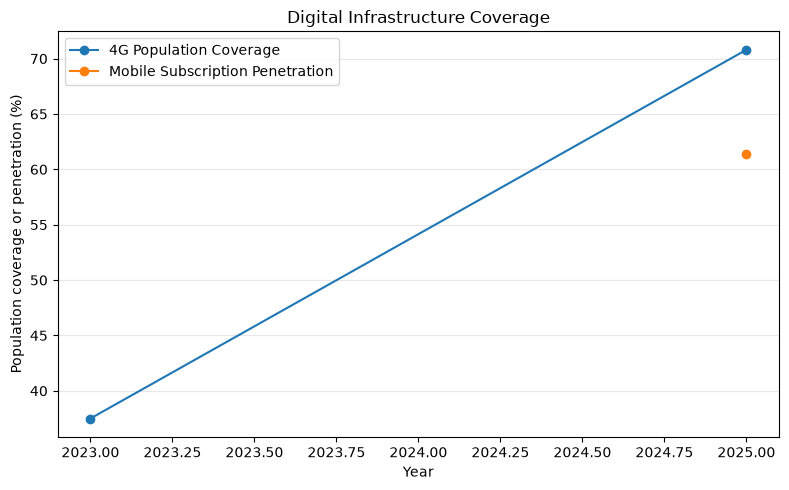

In [61]:
percentage_infrastructure = (
    infrastructure_data[
        infrastructure_data["unit"] == "%"
    ]
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

for indicator, group in (
    percentage_infrastructure
    .groupby("indicator")
):
    ax.plot(
        group["year"],
        group["value_numeric"],
        marker="o",
        label=indicator,
    )

ax.set_title(
    "Digital Infrastructure Coverage"
)

ax.set_xlabel("Year")
ax.set_ylabel("Population coverage or penetration (%)")

ax.legend()
ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

infrastructure_path = (
    FIGURES_DIR
    / "digital_infrastructure_coverage.png"
)

fig.savefig(
    infrastructure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [64]:
atm_related_data = observations_df[
    observations_df["indicator"]
    .str.contains(
        "ATM",
        case=False,
        na=False,
    )
][
    [
        "year",
        "indicator_code",
        "indicator",
        "value_numeric",
        "unit",
    ]
]

atm_related_data

,year,indicator_code,indicator,value_numeric,unit
17,2025,USG_ATM_COUNT,ATM Transaction Count,1.193000e+08,transactions
18,2025,USG_ATM_VALUE,ATM Transaction Value,1.561000e+11,ETB
19,2025,USG_CROSSOVER,P2P/ATM Crossover Ratio,1.080000e+00,ratio
66,2024,USG_ATM_COUNT,ATM Transaction Count,9.452774e+07,transactions


In [65]:
outcome_codes = [
    "ACC_OWNERSHIP",
    "ACC_MM_ACCOUNT",
    "USG_DIGITAL_PAYMENT_RATE",
]

inclusion_outcomes = (
    observations_df[
        observations_df["indicator_code"]
        .isin(outcome_codes)
    ][
        [
            "year",
            "indicator_code",
            "indicator",
            "value_numeric",
        ]
    ]
    .sort_values(
        [
            "indicator_code",
            "year",
        ]
    )
)

inclusion_outcomes

,year,indicator_code,indicator,value_numeric
6,2021,ACC_MM_ACCOUNT,Mobile Money Account Rate,4.70
7,2024,ACC_MM_ACCOUNT,Mobile Money Account Rate,9.45
57,2011,ACC_OWNERSHIP,Account Ownership Rate,14.00
0,2014,ACC_OWNERSHIP,Account Ownership Rate,22.00
1,2017,ACC_OWNERSHIP,Account Ownership Rate,35.00
2,2021,ACC_OWNERSHIP,Account Ownership Rate,46.00
3,2021,ACC_OWNERSHIP,Account Ownership Rate,56.00
4,2021,ACC_OWNERSHIP,Account Ownership Rate,36.00
5,2024,ACC_OWNERSHIP,Account Ownership Rate,49.00
58,2024,USG_DIGITAL_PAYMENT_RATE,Digital Payment Adoption Rate,35.00


In [66]:
relationship_results = []

for infrastructure_code in infrastructure_codes:

    infrastructure_series = (
        infrastructure_data[
            infrastructure_data["indicator_code"]
            == infrastructure_code
        ][
            [
                "year",
                "value_numeric",
            ]
        ]
        .rename(
            columns={
                "value_numeric":
                    "infrastructure_value"
            }
        )
    )

    for outcome_code in outcome_codes:

        outcome_series = (
            inclusion_outcomes[
                inclusion_outcomes[
                    "indicator_code"
                ] == outcome_code
            ][
                [
                    "year",
                    "value_numeric",
                ]
            ]
            .rename(
                columns={
                    "value_numeric":
                        "outcome_value"
                }
            )
        )

        merged = infrastructure_series.merge(
            outcome_series,
            on="year",
            how="inner",
        )

        correlation = None

        if len(merged) >= 3:
            correlation = round(
                merged[
                    "infrastructure_value"
                ].corr(
                    merged["outcome_value"]
                ),
                2,
            )

        relationship_results.append({
            "infrastructure_indicator":
                infrastructure_code,
            "outcome_indicator":
                outcome_code,
            "overlapping_years":
                len(merged),
            "correlation":
                correlation,
            "assessment": (
                "Enough data for basic correlation"
                if len(merged) >= 3
                else "Insufficient overlapping years"
            ),
        })

relationship_results = pd.DataFrame(
    relationship_results
)

relationship_results

,infrastructure_indicator,outcome_indicator,overlapping_years,correlation,assessment
0,ACC_4G_COV,ACC_OWNERSHIP,0,None,Insufficient overlapping years
1,ACC_4G_COV,ACC_MM_ACCOUNT,0,None,Insufficient overlapping years
2,ACC_4G_COV,USG_DIGITAL_PAYMENT_RATE,0,None,Insufficient overlapping years
3,ACC_MOBILE_PEN,ACC_OWNERSHIP,0,None,Insufficient overlapping years
4,ACC_MOBILE_PEN,ACC_MM_ACCOUNT,0,None,Insufficient overlapping years
5,ACC_MOBILE_PEN,USG_DIGITAL_PAYMENT_RATE,0,None,Insufficient overlapping years
6,ACC_TELEBIRR_AGENTS,ACC_OWNERSHIP,1,None,Insufficient overlapping years
7,ACC_TELEBIRR_AGENTS,ACC_MM_ACCOUNT,1,None,Insufficient overlapping years
8,ACC_TELEBIRR_AGENTS,USG_DIGITAL_PAYMENT_RATE,1,None,Insufficient overlapping years
9,ACC_FAYDA,ACC_OWNERSHIP,1,None,Insufficient overlapping years


In [67]:
leading_indicator_roles = {
    "ACC_4G_COV": {
        "potential_outcome": "Access and Usage",
        "reason": (
            "Expands availability of mobile-based "
            "financial services."
        ),
    },

    "ACC_MOBILE_PEN": {
        "potential_outcome": "Access and Usage",
        "reason": (
            "Shows the size of the population that can "
            "potentially reach mobile financial services."
        ),
    },

    "ACC_TELEBIRR_AGENTS": {
        "potential_outcome": "Access",
        "reason": (
            "Agents support registration, cash-in, "
            "cash-out and customer assistance."
        ),
    },

    "ACC_FAYDA": {
        "potential_outcome": "Access",
        "reason": (
            "Digital identification can reduce KYC "
            "and account-opening barriers."
        ),
    },

    "USG_TELEBIRR_MERCHANTS": {
        "potential_outcome": "Usage",
        "reason": (
            "Merchant acceptance provides more reasons "
            "to make digital payments."
        ),
    },
}

In [68]:
leading_indicators = (
    infrastructure_summary.copy()
)

leading_indicators[
    "potential_outcome"
] = leading_indicators[
    "indicator_code"
].map(
    lambda code:
        leading_indicator_roles[code][
            "potential_outcome"
        ]
)

leading_indicators[
    "reason"
] = leading_indicators[
    "indicator_code"
].map(
    lambda code:
        leading_indicator_roles[code][
            "reason"
        ]
)

leading_indicators[
    [
        "indicator_code",
        "indicator",
        "potential_outcome",
        "observation_count",
        "years_available",
        "reason",
    ]
]

,indicator_code,indicator,potential_outcome,observation_count,years_available,reason
0,ACC_4G_COV,4G Population Coverage,Access and Usage,2,"2023, 2025",Expands availability of mobile-based financial...
1,ACC_FAYDA,Fayda Digital ID Enrollment,Access,3,"2024, 2025",Digital identification can reduce KYC and acco...
2,ACC_MOBILE_PEN,Mobile Subscription Penetration,Access and Usage,1,2025,Shows the size of the population that can pote...
3,ACC_TELEBIRR_AGENTS,Telebirr Agent Count,Access,2,"2024, 2025","Agents support registration, cash-in, cash-out..."
4,USG_TELEBIRR_MERCHANTS,Telebirr Merchant Count,Usage,2,"2024, 2025",Merchant acceptance provides more reasons to m...


In [70]:
print("=" * 60)
print("INFRASTRUCTURE AND ENABLERS SUMMARY")
print("=" * 60)

print(
    "\nInfrastructure indicators:",
    infrastructure_data[
        "indicator_code"
    ].nunique(),
)

print(
    "Indicators with at least two years:",
    (
        infrastructure_summary[
            "observation_count"
        ] >= 2
    ).sum(),
)

print(
    "\nPotential leading indicators:",
    leading_indicators[
        "indicator_code"
    ].tolist(),
)

print(
    "\nFigure saved to:",
    infrastructure_path,
)

INFRASTRUCTURE AND ENABLERS SUMMARY

Infrastructure indicators: 5
Indicators with at least two years: 4

Potential leading indicators: ['ACC_4G_COV', 'ACC_FAYDA', 'ACC_MOBILE_PEN', 'ACC_TELEBIRR_AGENTS', 'USG_TELEBIRR_MERCHANTS']

Figure saved to: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\digital_infrastructure_coverage.png


# Event Timeline and Visual Analysis

In [71]:
from src.data_explorer import parse_dates

In [72]:
events_df = enriched_df[
    enriched_df["record_type"] == "event"
].copy()

events_df["observation_date"] = parse_dates(
    events_df["observation_date"]
)

events_df["year"] = (
    events_df["observation_date"]
    .dt.year
)

events_df = events_df[
    [
        "record_id",
        "observation_date",
        "year",
        "category",
        "indicator",
        "confidence",
    ]
].sort_values("observation_date").reset_index(drop=True)

events_df

,record_id,observation_date,year,category,indicator,confidence
0,EVT_0001,2021-05-17,2021,product_launch,Telebirr Launch,high
1,EVT_0009,2021-09-01,2021,policy,NFIS-II Strategy Launch,high
2,EVT_0002,2022-08-01,2022,market_entry,Safaricom Ethiopia Commercial Launch,high
3,EVT_0003,2023-08-01,2023,product_launch,M-Pesa Ethiopia Launch,high
4,EVT_0011,2023-10-09,2023,regulation,Revised Payment Instrument Issuer Directive,high
5,EVT_0004,2024-01-01,2024,infrastructure,Fayda Digital ID Program Rollout,high
6,EVT_0012,2024-02-29,2024,policy,National Financial Education Module Launch,high
7,EVT_0013,2024-04-05,2024,regulation,National Interoperable QR Payment Standard Launch,high
8,EVT_0005,2024-07-29,2024,policy,Foreign Exchange Liberalization,high
9,EVT_0006,2024-10-01,2024,milestone,P2P Transaction Count Surpasses ATM,high


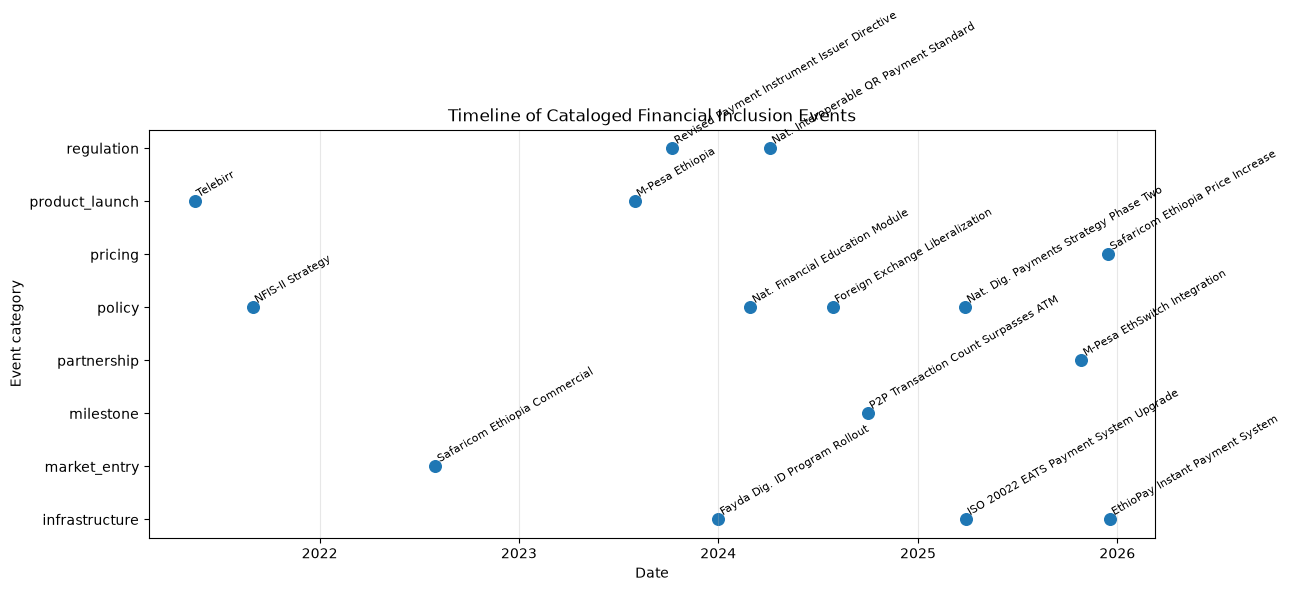

In [82]:
event_plot_df = events_df.copy()

event_plot_df["short_label"] = (
    event_plot_df["indicator"]
    .str.replace("Launch", "", regex=False)
    .str.replace("launched", "", regex=False)
    .str.replace("National", "Nat.", regex=False)
    .str.replace("Digital", "Dig.", regex=False)
    .str.strip()
)

category_positions = {
    category: i
    for i, category in enumerate(
        sorted(event_plot_df["category"].dropna().unique())
    )
}

event_plot_df["y_pos"] = event_plot_df["category"].map(category_positions)

fig, ax = plt.subplots(figsize=(13, 6))

ax.scatter(
    event_plot_df["observation_date"],
    event_plot_df["y_pos"],
    s=70,
)

for _, row in event_plot_df.iterrows():
    ax.text(
        row["observation_date"],
        row["y_pos"] + 0.08,
        row["short_label"],
        fontsize=8,
        rotation=30,
        ha="left",
    )

ax.set_yticks(list(category_positions.values()))
ax.set_yticklabels(list(category_positions.keys()))

ax.set_title("Timeline of Cataloged Financial Inclusion Events")
ax.set_xlabel("Date")
ax.set_ylabel("Event category")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

event_timeline_path = FIGURES_DIR / "event_timeline_improved.png"

fig.savefig(
    event_timeline_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [74]:
key_event_patterns = {
    "Telebirr launch": "telebirr",
    "Safaricom market entry": "safaricom",
    "M-Pesa launch": "m-pesa|mpesa",
}

key_events = []

for event_name, pattern in key_event_patterns.items():
    match = events_df[
        events_df["indicator"]
        .str.contains(
            pattern,
            case=False,
            na=False,
            regex=True,
        )
    ]

    if not match.empty:
        first_match = match.iloc[0]

        key_events.append({
            "event_name": event_name,
            "record_id": first_match["record_id"],
            "date": first_match["observation_date"],
            "year": first_match["year"],
            "category": first_match["category"],
            "indicator": first_match["indicator"],
        })

key_events = pd.DataFrame(key_events)

key_events

,event_name,record_id,date,year,category,indicator
0,Telebirr launch,EVT_0001,2021-05-17,2021,product_launch,Telebirr Launch
1,Safaricom market entry,EVT_0002,2022-08-01,2022,market_entry,Safaricom Ethiopia Commercial Launch
2,M-Pesa launch,EVT_0003,2023-08-01,2023,product_launch,M-Pesa Ethiopia Launch


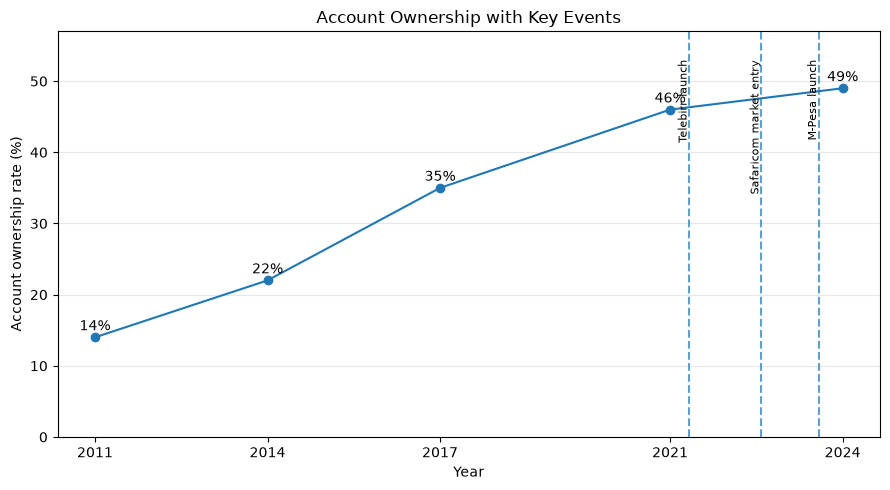

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    ownership_trajectory["year"],
    ownership_trajectory["ownership_rate"],
    marker="o",
)

for _, row in ownership_trajectory.iterrows():
    ax.text(
        row["year"],
        row["ownership_rate"] + 1,
        f'{row["ownership_rate"]:.0f}%',
        ha="center",
    )

for _, row in key_events.iterrows():
    event_year = row["date"].year + (
        row["date"].month - 1
    ) / 12

    ax.axvline(
        event_year,
        linestyle="--",
        alpha=0.7,
    )

    ax.text(
        event_year,
        ownership_trajectory["ownership_rate"].max() + 4,
        row["event_name"],
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
    )

ax.set_title(
    "Account Ownership with Key Events"
)

ax.set_xlabel("Year")
ax.set_ylabel("Account ownership rate (%)")
ax.set_xticks(ownership_trajectory["year"])
ax.set_ylim(
    0,
    ownership_trajectory["ownership_rate"].max() + 8,
)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

ownership_event_path = (
    FIGURES_DIR / "account_ownership_with_events.png"
)

fig.savefig(
    ownership_event_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

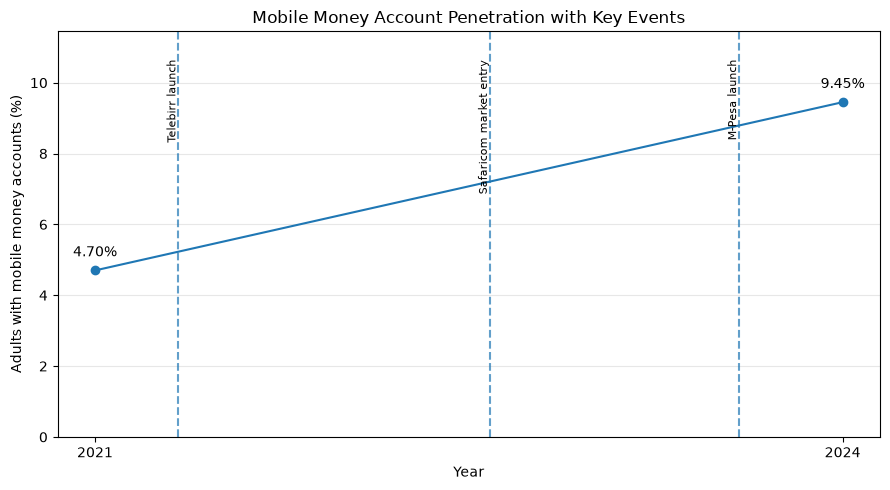

In [76]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    mobile_money_penetration["year"],
    mobile_money_penetration["value_numeric"],
    marker="o",
)

for _, row in mobile_money_penetration.iterrows():
    ax.text(
        row["year"],
        row["value_numeric"] + 0.4,
        f'{row["value_numeric"]:.2f}%',
        ha="center",
    )

for _, row in key_events.iterrows():
    event_year = row["date"].year + (
        row["date"].month - 1
    ) / 12

    ax.axvline(
        event_year,
        linestyle="--",
        alpha=0.7,
    )

    ax.text(
        event_year,
        mobile_money_penetration["value_numeric"].max() + 1.2,
        row["event_name"],
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
    )

ax.set_title(
    "Mobile Money Account Penetration with Key Events"
)

ax.set_xlabel("Year")
ax.set_ylabel("Adults with mobile money accounts (%)")
ax.set_xticks(mobile_money_penetration["year"])
ax.set_ylim(
    0,
    mobile_money_penetration["value_numeric"].max() + 2,
)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

mm_event_path = (
    FIGURES_DIR / "mobile_money_penetration_with_events.png"
)

fig.savefig(
    mm_event_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [77]:
coverage_4g = observations_df[
    observations_df["indicator_code"] == "ACC_4G_COV"
][
    [
        "year",
        "value_numeric",
        "indicator",
        "unit",
    ]
].sort_values("year").reset_index(drop=True)

coverage_4g

,year,value_numeric,indicator,unit
0,2023,37.5,4G Population Coverage,%
1,2025,70.8,4G Population Coverage,%


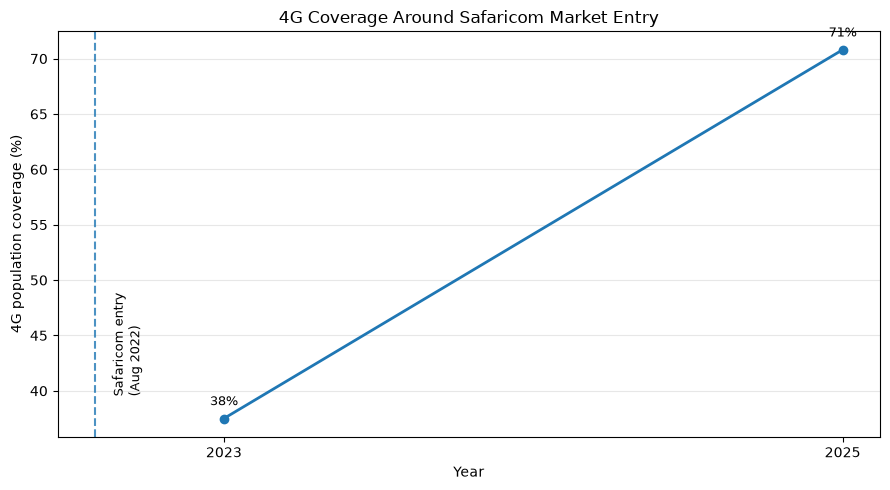

In [83]:
coverage_4g = observations_df[
    observations_df["indicator_code"] == "ACC_4G_COV"
][
    ["year", "value_numeric", "indicator", "unit"]
].sort_values("year").reset_index(drop=True)

safaricom_event = key_events[
    key_events["event_name"] == "Safaricom market entry"
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    coverage_4g["year"],
    coverage_4g["value_numeric"],
    marker="o",
    linewidth=2,
)

for _, row in coverage_4g.iterrows():
    ax.text(
        row["year"],
        row["value_numeric"] + 1.2,
        f'{row["value_numeric"]:.0f}%',
        ha="center",
        fontsize=9,
    )

if not safaricom_event.empty:
    row = safaricom_event.iloc[0]
    event_x = row["date"].year + (row["date"].month - 1) / 12

    ax.axvline(
        event_x,
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
    )

    ax.text(
        event_x + 0.05,
        coverage_4g["value_numeric"].min() + 2,
        "Safaricom entry\n(Aug 2022)",
        rotation=90,
        va="bottom",
        ha="left",
        fontsize=9,
    )

ax.set_title("4G Coverage Around Safaricom Market Entry")
ax.set_xlabel("Year")
ax.set_ylabel("4G population coverage (%)")
ax.set_xticks(sorted(coverage_4g["year"].unique()))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

safaricom_4g_path = (
    FIGURES_DIR / "safaricom_entry_4g_coverage_improved.png"
)

fig.savefig(
    safaricom_4g_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [79]:
before_after_summary = pd.DataFrame({
    "indicator": [
        "Account Ownership Rate",
        "Mobile Money Account Penetration",
        "4G Coverage",
    ],
    "before_event_value": [
        ownership_trajectory.loc[
            ownership_trajectory["year"] == 2021,
            "ownership_rate",
        ].iloc[0],

        mobile_money_penetration.loc[
            mobile_money_penetration["year"] == 2021,
            "value_numeric",
        ].iloc[0],

        coverage_4g.loc[
            coverage_4g["year"] == 2021,
            "value_numeric",
        ].iloc[0] if 2021 in coverage_4g["year"].values else None,
    ],
    "latest_available_value": [
        ownership_trajectory.loc[
            ownership_trajectory["year"] == 2024,
            "ownership_rate",
        ].iloc[0],

        mobile_money_penetration.loc[
            mobile_money_penetration["year"] == 2024,
            "value_numeric",
        ].iloc[0],

        coverage_4g.loc[
            coverage_4g["year"] == 2025,
            "value_numeric",
        ].iloc[0] if 2025 in coverage_4g["year"].values else None,
    ],
})
before_after_summary["change"] = (
    before_after_summary["latest_available_value"]
    - before_after_summary["before_event_value"]
)

before_after_summary

,indicator,before_event_value,latest_available_value,change
0,Account Ownership Rate,46.0,49.00,3.00
1,Mobile Money Account Penetration,4.7,9.45,4.75
2,4G Coverage,NaN,70.80,NaN


In [80]:
print("=" * 60)
print("EVENT TIMELINE AND VISUAL ANALYSIS SUMMARY")
print("=" * 60)

print(
    "\nTotal cataloged events:",
    len(events_df),
)

print(
    "Key events identified:",
    len(key_events),
)

print(
    "\nTimeline figure:",
    event_timeline_path,
)

print(
    "Account ownership + events figure:",
    ownership_event_path,
)

print(
    "Mobile money + events figure:",
    mm_event_path,
)

print(
    "Safaricom + 4G figure:",
    safaricom_4g_path,
)

EVENT TIMELINE AND VISUAL ANALYSIS SUMMARY

Total cataloged events: 15
Key events identified: 3

Timeline figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\event_timeline.png
Account ownership + events figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\account_ownership_with_events.png
Mobile money + events figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\mobile_money_penetration_with_events.png
Safaricom + 4G figure: C:\Users\bemnet\Desktop\10academy\newWeek11\new-ethiopia-fi-forcast\reports\figures\safaricom_entry_4g_coverage.png


# Correlation Analysis

In [84]:
corr_df = observations_df.copy()

corr_df["value_numeric"] = pd.to_numeric(
    corr_df["value_numeric"],
    errors="coerce",
)

corr_df["gender_clean"] = (
    corr_df["gender"]
    .fillna("all")
    .astype(str)
    .str.lower()
    .str.strip()
)

corr_df["location_clean"] = (
    corr_df["location"]
    .fillna("national")
    .astype(str)
    .str.lower()
    .str.strip()
)

# keep mostly national / overall observations
corr_df = corr_df[
    (corr_df["gender_clean"] == "all")
    & (corr_df["location_clean"] == "national")
].copy()

corr_df = corr_df[
    [
        "year",
        "indicator_code",
        "indicator",
        "pillar",
        "value_numeric",
    ]
].dropna(subset=["value_numeric"])

In [85]:
corr_wide = corr_df.pivot_table(
    index="year",
    columns="indicator_code",
    values="value_numeric",
    aggfunc="mean",
)

corr_wide

indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,ACC_TELEBIRR_AGENTS,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_GAP_MOBILE,USG_ACTIVE_AGENT_RATE,...,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_POS_COUNT,USG_POS_VALUE,USG_SECTOR_ACTIVE_ACCOUNT_RATE,USG_TELEBIRR_MERCHANTS,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE
year,,,,,,,,,,,,,,,,,,,,,
2011,NaN,NaN,NaN,NaN,14.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017,NaN,NaN,NaN,NaN,35.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,NaN,NaN,4.70,NaN,46.0,NaN,NaN,20.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,37.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024,NaN,8000000.0,9.45,NaN,49.0,216000.0,2.0,18.0,24.0,NaN,...,7100000.0,10800000.0,49700000.0,NaN,2181365.0,NaN,NaN,196000.0,47500000.0,1.810000e+12
2025,70.8,13500000.0,NaN,61.4,NaN,320300.0,NaN,NaN,NaN,25.0,...,NaN,NaN,128300000.0,5.777000e+11,2780000.0,7.200000e+09,15.0,310100.0,54840000.0,2.380000e+12


In [86]:
correlation_matrix = corr_wide.corr()

correlation_matrix

indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,ACC_TELEBIRR_AGENTS,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_GAP_MOBILE,USG_ACTIVE_AGENT_RATE,...,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_POS_COUNT,USG_POS_VALUE,USG_SECTOR_ACTIVE_ACCOUNT_RATE,USG_TELEBIRR_MERCHANTS,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE
indicator_code,,,,,,,,,,,,,,,,,,,,,
ACC_4G_COV,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_FAYDA,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,1.0,1.0
ACC_MM_ACCOUNT,NaN,NaN,1.0,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_MOBILE_PEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_OWNERSHIP,NaN,NaN,1.0,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_TELEBIRR_AGENTS,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,1.0,1.0
AFF_DATA_INCOME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_GAP_ACC,NaN,NaN,-1.0,NaN,-1.0,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_GAP_MOBILE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
access_target = "ACC_OWNERSHIP"

access_results = []

for column in corr_wide.columns:
    if column == access_target:
        continue

    temp = corr_wide[[access_target, column]].dropna()

    overlap = len(temp)

    corr_value = None
    if overlap >= 2:
        corr_value = round(
            temp[access_target].corr(temp[column]),
            2,
        )

    access_results.append({
        "factor_code": column,
        "overlapping_years": overlap,
        "correlation_with_access": corr_value,
    })

access_results = pd.DataFrame(access_results)

access_results = access_results.sort_values(
    ["overlapping_years", "correlation_with_access"],
    ascending=[False, False],
).reset_index(drop=True)

access_results

,factor_code,overlapping_years,correlation_with_access
0,ACC_MM_ACCOUNT,2,1.0
1,GEN_GAP_ACC,2,-1.0
2,ACC_FAYDA,1,NaN
3,ACC_TELEBIRR_AGENTS,1,NaN
4,AFF_DATA_INCOME,1,NaN
5,GEN_GAP_MOBILE,1,NaN
6,USG_ACTIVE_RATE,1,NaN
7,USG_ATM_COUNT,1,NaN
8,USG_DIGITAL_PAYMENT_RATE,1,NaN
9,USG_DIGITAL_TXN_VALUE,1,NaN


In [88]:
indicator_lookup = (
    corr_df[
        ["indicator_code", "indicator", "pillar"]
    ]
    .drop_duplicates()
)

access_results = access_results.merge(
    indicator_lookup,
    left_on="factor_code",
    right_on="indicator_code",
    how="left",
)

access_results[
    [
        "factor_code",
        "indicator",
        "pillar",
        "overlapping_years",
        "correlation_with_access",
    ]
]

,factor_code,indicator,pillar,overlapping_years,correlation_with_access
0,ACC_MM_ACCOUNT,Mobile Money Account Rate,ACCESS,2,1.0
1,GEN_GAP_ACC,Account Ownership Gender Gap,GENDER,2,-1.0
2,ACC_FAYDA,Fayda Digital ID Enrollment,ACCESS,1,NaN
3,ACC_TELEBIRR_AGENTS,Telebirr Agent Count,ACCESS,1,NaN
4,AFF_DATA_INCOME,Data Affordability Index,AFFORDABILITY,1,NaN
5,GEN_GAP_MOBILE,Mobile Phone Gender Gap,GENDER,1,NaN
6,USG_ACTIVE_RATE,Mobile Money Activity Rate,USAGE,1,NaN
7,USG_ATM_COUNT,ATM Transaction Count,USAGE,1,NaN
8,USG_DIGITAL_PAYMENT_RATE,Digital Payment Adoption Rate,USAGE,1,NaN
9,USG_DIGITAL_TXN_VALUE,Total Digital Transaction Value,USAGE,1,NaN


In [89]:
usage_target = "USG_DIGITAL_PAYMENT_RATE"

if usage_target in corr_wide.columns:
    print(
        "Available years for digital payment adoption:",
        corr_wide[usage_target].dropna().index.tolist()
    )
else:
    print("Usage outcome not found.")

Available years for digital payment adoption: [2024]


## Proxy indicators for Usage

In [90]:
usage_proxy_codes = [
    "ACC_MM_ACCOUNT",
    "USG_TELEBIRR_USERS",
    "USG_MPESA_USERS",
    "USG_MPESA_ACTIVE",
    "USG_P2P_COUNT",
    "USG_POS_COUNT",
    "USG_TELEBIRR_MERCHANTS",
    "USG_ACTIVE_RATE",
    "USG_SECTOR_ACTIVE_ACCOUNT_RATE",
]

available_usage_proxies = [
    code for code in usage_proxy_codes
    if code in corr_wide.columns
]

available_usage_proxies

['ACC_MM_ACCOUNT',
 'USG_TELEBIRR_USERS',
 'USG_MPESA_USERS',
 'USG_MPESA_ACTIVE',
 'USG_P2P_COUNT',
 'USG_POS_COUNT',
 'USG_TELEBIRR_MERCHANTS',
 'USG_ACTIVE_RATE',
 'USG_SECTOR_ACTIVE_ACCOUNT_RATE']

In [91]:
usage_proxy_target = "ACC_MM_ACCOUNT"

usage_results = []

for column in available_usage_proxies:
    if column == usage_proxy_target:
        continue

    temp = corr_wide[[usage_proxy_target, column]].dropna()

    overlap = len(temp)

    corr_value = None
    if overlap >= 2:
        corr_value = round(
            temp[usage_proxy_target].corr(temp[column]),
            2,
        )

    usage_results.append({
        "factor_code": column,
        "overlapping_years": overlap,
        "correlation_with_mm_accounts": corr_value,
    })

usage_results = pd.DataFrame(usage_results)

usage_results = usage_results.merge(
    indicator_lookup,
    left_on="factor_code",
    right_on="indicator_code",
    how="left",
)

usage_results[
    [
        "factor_code",
        "indicator",
        "pillar",
        "overlapping_years",
        "correlation_with_mm_accounts",
    ]
].sort_values(
    ["overlapping_years", "correlation_with_mm_accounts"],
    ascending=[False, False],
).reset_index(drop=True)

,factor_code,indicator,pillar,overlapping_years,correlation_with_mm_accounts
0,USG_TELEBIRR_USERS,Telebirr Registered Users,USAGE,1,None
1,USG_MPESA_USERS,M-Pesa Registered Users,USAGE,1,None
2,USG_MPESA_ACTIVE,M-Pesa 90-Day Active Users,USAGE,1,None
3,USG_P2P_COUNT,P2P Transaction Count,USAGE,1,None
4,USG_POS_COUNT,POS Transaction Count,USAGE,1,None
5,USG_TELEBIRR_MERCHANTS,Telebirr Merchant Count,USAGE,1,None
6,USG_ACTIVE_RATE,Mobile Money Activity Rate,USAGE,1,None
7,USG_SECTOR_ACTIVE_ACCOUNT_RATE,Sector Active Mobile Money Account Rate,USAGE,0,None


In [92]:
def label_reliability(overlap):
    if overlap >= 4:
        return "Stronger"
    elif overlap == 3:
        return "Limited"
    elif overlap == 2:
        return "Very weak"
    else:
        return "Not enough data"

access_results["reliability"] = access_results[
    "overlapping_years"
].apply(label_reliability)

usage_results["reliability"] = usage_results[
    "overlapping_years"
].apply(label_reliability)

In [93]:
access_results[
    [
        "factor_code",
        "indicator",
        "overlapping_years",
        "correlation_with_access",
        "reliability",
    ]
].sort_values(
    ["overlapping_years", "correlation_with_access"],
    ascending=[False, False],
).reset_index(drop=True)

,factor_code,indicator,overlapping_years,correlation_with_access,reliability
0,ACC_MM_ACCOUNT,Mobile Money Account Rate,2,1.0,Very weak
1,GEN_GAP_ACC,Account Ownership Gender Gap,2,-1.0,Very weak
2,ACC_FAYDA,Fayda Digital ID Enrollment,1,NaN,Not enough data
3,ACC_TELEBIRR_AGENTS,Telebirr Agent Count,1,NaN,Not enough data
4,AFF_DATA_INCOME,Data Affordability Index,1,NaN,Not enough data
5,GEN_GAP_MOBILE,Mobile Phone Gender Gap,1,NaN,Not enough data
6,USG_ACTIVE_RATE,Mobile Money Activity Rate,1,NaN,Not enough data
7,USG_ATM_COUNT,ATM Transaction Count,1,NaN,Not enough data
8,USG_DIGITAL_PAYMENT_RATE,Digital Payment Adoption Rate,1,NaN,Not enough data
9,USG_DIGITAL_TXN_VALUE,Total Digital Transaction Value,1,NaN,Not enough data


In [94]:
usage_results[
    [
        "factor_code",
        "indicator",
        "overlapping_years",
        "correlation_with_mm_accounts",
        "reliability",
    ]
].sort_values(
    ["overlapping_years", "correlation_with_mm_accounts"],
    ascending=[False, False],
).reset_index(drop=True)

,factor_code,indicator,overlapping_years,correlation_with_mm_accounts,reliability
0,USG_TELEBIRR_USERS,Telebirr Registered Users,1,None,Not enough data
1,USG_MPESA_USERS,M-Pesa Registered Users,1,None,Not enough data
2,USG_MPESA_ACTIVE,M-Pesa 90-Day Active Users,1,None,Not enough data
3,USG_P2P_COUNT,P2P Transaction Count,1,None,Not enough data
4,USG_POS_COUNT,POS Transaction Count,1,None,Not enough data
5,USG_TELEBIRR_MERCHANTS,Telebirr Merchant Count,1,None,Not enough data
6,USG_ACTIVE_RATE,Mobile Money Activity Rate,1,None,Not enough data
7,USG_SECTOR_ACTIVE_ACCOUNT_RATE,Sector Active Mobile Money Account Rate,0,None,Not enough data


## Impact Link analysis

In [95]:
impact_df = enriched_df[
    enriched_df["record_type"] == "impact_link"
].copy()

impact_df[
    [
        "record_id",
        "parent_id",
        "pillar",
        "related_indicator",
        "relationship_type",
        "impact_direction",
        "impact_magnitude",
        "evidence_basis",
        "confidence",
    ]
].head()

,record_id,parent_id,pillar,related_indicator,relationship_type,impact_direction,impact_magnitude,evidence_basis,confidence
43,IMP_0001,EVT_0001,ACCESS,ACC_OWNERSHIP,direct,increase,high,literature,medium
44,IMP_0002,EVT_0001,USAGE,USG_TELEBIRR_USERS,direct,increase,high,empirical,high
45,IMP_0003,EVT_0001,USAGE,USG_P2P_COUNT,direct,increase,high,empirical,medium
46,IMP_0004,EVT_0002,ACCESS,ACC_4G_COV,direct,increase,medium,empirical,medium
47,IMP_0005,EVT_0002,AFFORDABILITY,AFF_DATA_INCOME,indirect,decrease,medium,literature,medium


In [96]:
impact_by_pillar = (
    impact_df["pillar"]
    .value_counts()
    .reset_index()
)

impact_by_pillar.columns = [
    "pillar",
    "impact_link_count",
]

impact_by_pillar

,pillar,impact_link_count
0,USAGE,13
1,ACCESS,6
2,AFFORDABILITY,3
3,GENDER,1


In [97]:
impact_by_relationship = (
    impact_df["relationship_type"]
    .value_counts()
    .reset_index()
)

impact_by_relationship.columns = [
    "relationship_type",
    "count",
]

impact_by_relationship

,relationship_type,count
0,direct,11
1,enabling,7
2,indirect,5


In [98]:
impact_by_direction = (
    impact_df["impact_direction"]
    .value_counts()
    .reset_index()
)

impact_by_direction.columns = [
    "impact_direction",
    "count",
]

impact_by_direction

,impact_direction,count
0,increase,21
1,decrease,2


In [99]:
impact_target_summary = (
    impact_df["related_indicator"]
    .value_counts()
    .reset_index()
)

impact_target_summary.columns = [
    "related_indicator",
    "link_count",
]

impact_target_summary

,related_indicator,link_count
0,USG_P2P_COUNT,4
1,ACC_OWNERSHIP,3
2,AFF_DATA_INCOME,3
3,USG_DIGITAL_PAYMENT_RATE,3
4,ACC_MM_ACCOUNT,2
5,USG_TELEBIRR_USERS,1
6,ACC_4G_COV,1
7,USG_MPESA_USERS,1
8,GEN_GAP_ACC,1
9,USG_MPESA_ACTIVE,1


In [100]:
impact_target_summary = impact_target_summary.merge(
    indicator_lookup,
    left_on="related_indicator",
    right_on="indicator_code",
    how="left",
)

impact_target_summary[
    [
        "related_indicator",
        "indicator",
        "pillar",
        "link_count",
    ]
]

,related_indicator,indicator,pillar,link_count
0,USG_P2P_COUNT,P2P Transaction Count,USAGE,4
1,ACC_OWNERSHIP,Account Ownership Rate,ACCESS,3
2,AFF_DATA_INCOME,Data Affordability Index,AFFORDABILITY,3
3,USG_DIGITAL_PAYMENT_RATE,Digital Payment Adoption Rate,USAGE,3
4,ACC_MM_ACCOUNT,Mobile Money Account Rate,ACCESS,2
5,USG_TELEBIRR_USERS,Telebirr Registered Users,USAGE,1
6,ACC_4G_COV,4G Population Coverage,ACCESS,1
7,USG_MPESA_USERS,M-Pesa Registered Users,USAGE,1
8,GEN_GAP_ACC,Account Ownership Gender Gap,GENDER,1
9,USG_MPESA_ACTIVE,M-Pesa 90-Day Active Users,USAGE,1


In [101]:
event_lookup = enriched_df[
    enriched_df["record_type"] == "event"
][
    ["record_id", "indicator", "category"]
].drop_duplicates()

event_lookup = event_lookup.rename(
    columns={
        "record_id": "parent_id",
        "indicator": "event_name",
        "category": "event_category",
    }
)

impact_event_details = impact_df.merge(
    event_lookup,
    on="parent_id",
    how="left",
)

impact_event_details[
    [
        "parent_id",
        "event_name",
        "event_category",
        "pillar",
        "related_indicator",
        "relationship_type",
        "impact_direction",
        "impact_magnitude",
        "evidence_basis",
    ]
].sort_values(
    ["event_name", "pillar"]
).reset_index(drop=True)

,parent_id,event_name,event_category,pillar,related_indicator,relationship_type,impact_direction,impact_magnitude,evidence_basis
0,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,USAGE,USG_P2P_COUNT,indirect,increase,medium,literature
1,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,ACCESS,ACC_OWNERSHIP,enabling,increase,medium,literature
2,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,GENDER,GEN_GAP_ACC,indirect,decrease,medium,literature
3,EVT_0005,Foreign Exchange Liberalization,policy,AFFORDABILITY,AFF_DATA_INCOME,indirect,increase,high,empirical
4,EVT_0015,ISO 20022 EATS Payment System Upgrade,infrastructure,USAGE,USG_DIGITAL_TXN_VALUE,enabling,increase,low,theoretical
5,EVT_0015,ISO 20022 EATS Payment System Upgrade,infrastructure,USAGE,USG_P2P_COUNT,indirect,increase,low,theoretical
6,EVT_0007,M-Pesa EthSwitch Integration,partnership,USAGE,USG_MPESA_ACTIVE,direct,increase,medium,literature
7,EVT_0007,M-Pesa EthSwitch Integration,partnership,USAGE,USG_P2P_COUNT,direct,increase,medium,literature
8,EVT_0003,M-Pesa Ethiopia Launch,product_launch,ACCESS,ACC_MM_ACCOUNT,direct,increase,medium,theoretical
9,EVT_0003,M-Pesa Ethiopia Launch,product_launch,USAGE,USG_MPESA_USERS,direct,increase,high,empirical


In [102]:
links_per_event = (
    impact_event_details["event_name"]
    .value_counts()
    .reset_index()
)

links_per_event.columns = [
    "event_name",
    "impact_link_count",
]

links_per_event

,event_name,impact_link_count
0,Telebirr Launch,3
1,Safaricom Ethiopia Commercial Launch,2
2,M-Pesa Ethiopia Launch,2
3,Fayda Digital ID Program Rollout,2
4,M-Pesa EthSwitch Integration,2
5,Revised Payment Instrument Issuer Directive,2
6,National Interoperable QR Payment Standard Launch,2
7,National Digital Payments Strategy Phase Two L...,2
8,ISO 20022 EATS Payment System Upgrade,2
9,Foreign Exchange Liberalization,1


In [103]:
print("=" * 60)
print("CORRELATION ANALYSIS SUMMARY")
print("=" * 60)

print(
    "\nIndicators in correlation table:",
    corr_wide.shape[1],
)

print(
    "Years in correlation table:",
    corr_wide.shape[0],
)

print(
    "\nAccess factors with at least 2 overlapping years:",
    (access_results["overlapping_years"] >= 2).sum(),
)

print(
    "Usage proxy factors with at least 2 overlapping years:",
    (usage_results["overlapping_years"] >= 2).sum(),
)

print(
    "\nDirect Usage outcome available years:",
    corr_wide["USG_DIGITAL_PAYMENT_RATE"].dropna().shape[0]
    if "USG_DIGITAL_PAYMENT_RATE" in corr_wide.columns else 0,
)

print(
    "\nImpact links:",
    len(impact_df),
)

print(
    "Distinct impacted indicators:",
    impact_df["related_indicator"].nunique(),
)

print(
    "Distinct parent events:",
    impact_df["parent_id"].nunique(),
)

CORRELATION ANALYSIS SUMMARY

Indicators in correlation table: 26
Years in correlation table: 7

Access factors with at least 2 overlapping years: 2
Usage proxy factors with at least 2 overlapping years: 0

Direct Usage outcome available years: 1

Impact links: 23
Distinct impacted indicators: 13
Distinct parent events: 13
